# BETO FINE TUNING

In [1]:
import numpy as np 
import pandas as pd 
import pickle
from rich import print
from time import perf_counter
from tqdm import tqdm
from glob import glob
import os
import io

# from tensorflow.keras.preprocessing.sequence import pad_sequences

# We'll use a pretrained model, so we will be implementing transformers
from transformers import BertTokenizer, BertConfig, BertForSequenceClassification
from transformers import AutoTokenizer, AutoModelForMaskedLM, AdamW

# "train_test_split" allows us to split the data easily (we need a validation data set)
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder

# We'll be using PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler, Dataset

# Tweets Package manager
from tidyX import TextPreprocessor as tp

# copy is needed for creating a copy of the original pretrained model (Beto) and then modify it...
import copy

# for visualizing the data...
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Paths
path = r"/mnt/disk2/Data"
path_3_day = os.path.join(path,"3_Day_Graphs")
path_daily = os.path.join(path,"Daily_Graphs")

In [2]:
# Setting a seed will allow us to easily keep track of effects that occur when we make a change in 
# the model's architecture.
# Basically, seed() is used to initialize the random number generator.
seed = 1
np.random.seed(seed)
torch.manual_seed(seed)

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Importar Tweets

In [4]:
# Open retweets edge list in any case
tweets_pre = (
    pd.read_pickle(os.path.join(path, "Tweets_DataFrames", "tweets_presample.gzip"), compression = "gzip")
    .rename(columns = {'ID': 'Tweet ID'})
    .loc[:,['Tweet ID', 'Author ID', 'Referenced Tweet Author ID', 'Text', 'Reference Type']]
)

tweets_pre['Reference Type'].value_counts(dropna=False).apply(lambda x: f"{x:,}")

Reference Type
retweeted     6,627,052
replied_to    2,398,385
NaN           1,773,470
quoted          519,027
Name: count, dtype: object

In [30]:
tweets_pre.loc[tweets_pre['Reference Type'].isna(),'Reference Type'] = 'original_tweet'

pre_tweets_originales = tweets_pre.loc[tweets_pre['Reference Type']=='original_tweet',:]
pre_retweets = tweets_pre.loc[tweets_pre['Reference Type']=='retweeted',:]

# Cargar mapa de Silla + Congresistas
with open(os.path.join(path,"Pickle","User_Dicts","mapa_full.pkl"), "rb") as file:
    mapa = pickle.load(file)

pre_tweets_originales.loc[:,'Party'] = pre_tweets_originales.loc[:,"Author ID"].map(mapa)
pre_retweets.loc[:,'Party'] = pre_retweets.loc[:,"Referenced Tweet Author ID"].map(mapa)

print("Clasificación de Tweets originales según el Author ID")
print(pre_tweets_originales.value_counts('Party',dropna=False).apply(lambda x: f"{x:,}"))
print("Clasificación de Retweets siguiendo el criterio del testimonio\n(El retweet se clasifica según a quien se retweeta)")
print(pre_retweets.value_counts('Party',dropna=False).apply(lambda x: f"{x:,}"))

pre_tweets_originales_NPD = pre_tweets_originales.loc[pre_tweets_originales['Party'].isna(),:]
test_BETO = pre_tweets_originales_NPD.sample(n = 2_000)[['Tweet ID', 'Text']]
test_BETO.head(3)

Clasificación de Tweets originales según el Author ID

Party
NaN          1,760,137
Izquierda        5,363
Derecha          4,130
Centro           3,840
Name: count, dtype: object

Clasificación de Retweets siguiendo el criterio del testimonio
(El retweet se clasifica según a quien se retweeta)

Party
NaN          5,671,099
Izquierda      578,238
Derecha        236,454
Centro         141,261
Name: count, dtype: object

,Tweet ID,Text
4942889,1.355129e+18,#ConsejoTA “Que Colombia tenga una puntuación ...
2940110,1.353138e+18,Así suena la conversación entre @juanchosargen...
9344327,1.188761e+18,Monchy Geovany Moreno elegido nuevamente como ...


In [40]:
train_tweets_originales = (
    pre_tweets_originales
    .loc[pre_tweets_originales['Party'].notna(),['Tweet ID', 'Text', 'Party']]
)

train_retweets = (
    pre_retweets
    .loc[pre_retweets['Party'].notna(),['Tweet ID', 'Text', 'Party']]
)

train_BETO = pd.concat([train_tweets_originales,train_retweets])
train_BETO = train_BETO.sample(n = 5_000)[['Tweet ID', 'Text','Party']]
print(f"Número de tweets originales y retweets etiquetados {len(train_BETO):,}")
print(f"Número de tweets sin clasificación (testeo) {len(test_BETO):,}")
train_BETO.head()

Número de tweets originales y retweets etiquetados 5,000

Número de tweets sin clasificación (testeo) 2,000

,Tweet ID,Text,Party
6823156,1.185040e+18,RT @YoAlejoV: El presidente de Colombia no es ...,Izquierda
6880458,1.185184e+18,RT @JulianRoman: Cómo será la reforma laboral ...,Izquierda
6552655,1.184671e+18,RT @HOLLMANMORRIS: En nuestra Alcaldía Bogotá ...,Izquierda
10086952,1.189856e+18,RT @ArielAnaliza: Cambiar al Ministro @Guiller...,Centro
5980930,1.183801e+18,RT @MONYRODRIGUEZOF: Va a representar pero a l...,Izquierda


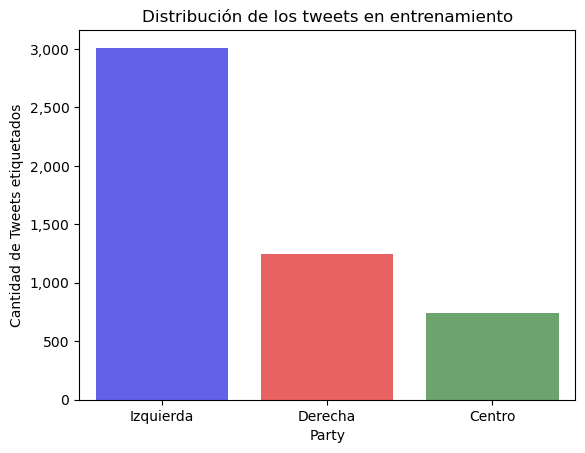

In [41]:
temp = train_BETO.value_counts('Party')
from matplotlib import ticker
fig, ax = plt.subplots()
sns.barplot(x = temp.index, y = temp, palette = ['blue', 'red', 'forestgreen'],hue = temp.index, alpha = 0.7,ax = ax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}"))
plt.ylabel('Cantidad de Tweets etiquetados')
plt.title("Distribución de los tweets en entrenamiento")
plt.show()

In [44]:
def preprocess_tweets(top_affiliation_tweets:pd.Series):
      
    # Each input text should start with "query: " or "passage: ", even for non-English texts.
    # For tasks other than retrieval, you can simply use the "query: " prefix.
    tqdm.pandas()
    top_affiliation_tweets = top_affiliation_tweets.progress_apply(lambda x: tp.preprocess(str(x)))
    top_affiliation_tweets = "passage: " + top_affiliation_tweets
    input_texts = top_affiliation_tweets.values
    
    return input_texts

train_inputs = preprocess_tweets(train_BETO['Text'])
# train_inputs = train_BETO['Text'].values
train_labels = train_BETO['Party'].values
dev_size = 0.15

# Convert string labels to integers
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(train_labels)

print(label_encoder.classes_)

100%|██████████| 5000/5000 [00:01<00:00, 4778.83it/s]


['Centro' 'Derecha' 'Izquierda']

In [45]:
train_inputs, dev_inputs, train_labels, dev_labels = train_test_split(
    train_inputs, 
    encoded_labels,
    test_size=dev_size,
    stratify=encoded_labels
)

print(encoded_labels)  # This will output numerical labels like [2, 1, 0]
print(f'Number of tweets (training data set): {train_inputs.shape[0]:,}')
print(f'Number of tweets (validation data set): {dev_inputs.shape[0]:,}')

[2 2 2 ... 0 2 2]

Number of tweets (training data set): 4,250

Number of tweets (validation data set): 750

# Modelo BETO

In [46]:
# Define and import the tokenizer...
tokenizer = BertTokenizer.from_pretrained('dccuchile/bert-base-spanish-wwm-cased', do_lower_case=True)

# Import BETO
model = BertForSequenceClassification.from_pretrained("dccuchile/bert-base-spanish-wwm-cased", num_labels=3)

# Parameters for training
param_optimizer = list(model.named_parameters())
no_decay = ['bias', 'gamma', 'beta']
optimizer_grouped_parameters = [
    {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.01},
    {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.0}
]

# Define hyperparameters...
batch_size = 256
learning_rate = 1e-6
optimizer = AdamW(optimizer_grouped_parameters, lr=learning_rate, correct_bias=False)

criterion = torch.nn.CrossEntropyLoss().to(device)
epochs = 5

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# DataSet

In [47]:
class createDataset(Dataset):

    def __init__(self, texts, targets, tokenizer, max_len):
        self.texts = texts
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len
  
    def __len__(self):
        return len(self.texts)
  
    def __getitem__(self, item):
        text = str(self.texts[item])
        target = self.targets[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            pad_to_max_length=True,
            return_attention_mask=True,
            return_tensors='pt',
            truncation=True
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(target, dtype=torch.long)
        }

def create_data_loader(texts, labels, tokenizer, max_len, batch_size):
    ds = createDataset(
        texts=texts,
        targets=labels,
        tokenizer=tokenizer,
        max_len=max_len
  )

    return DataLoader(
        ds,
        batch_size=batch_size,
        num_workers=10
      )
    
max_secuence_length = 100

train_data_loader = create_data_loader(train_inputs, encoded_labels, tokenizer, max_secuence_length, batch_size)
dev_data_loader = create_data_loader(dev_inputs, dev_labels, tokenizer, max_secuence_length, batch_size)

# Entrenamiento

In [48]:
# This method shows what's needs to be done during an epoch for training the model...
def train_an_epoch(
    model, 
    train_data_loader,
    dev_data_loader,
    criterion, 
    optimizer
):

    # These are the metrics that will indicate us how well it's doing the model...
    running_loss = 0
    running_accs = 0
    steps = 0;
    
    for batch in train_data_loader:
        
        # Clean gradients...
        optimizer.zero_grad()
    
        # Get the information from the tokenization... (using GPU)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["targets"].to(device)
        
        # get the model's predictions...
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        #targets = torch.reshape(targets, (targets.shape[0], 1))
        
        # Apply the loss function and the perform backward propagation...
    
        loss = criterion(outputs.logits, targets)
        loss.backward() 
        optimizer.step()
        
        # Get the predicted class (highest probability)
        predictions = torch.argmax(outputs.logits, dim=1)  # logits has shape [batch_size, num_classes]
        
        # Calculate accuracy by comparing predicted classes with targets
        acc = torch.eq(predictions, targets).float().mean()
        
        running_loss = loss.item()
        running_loss += loss.item();
        running_accs += acc.item()
        steps+=1
            
    # get the mean of the metrics...
    loss = running_loss/steps;
    acc = running_accs/steps;
    
    # evaluate the model with the validation data set 
    # ("turn off" gradients...)
    with torch.no_grad():
        
        # These are the metrics that will indicate us how well it's doing the model...
        epoch_accs_val=0;
        steps_val=0;
        
        for batch in dev_data_loader:
            
            # Get the information from the tokenization... (using GPU)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["targets"].to(device)
        
            # get the model's predictions...
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            # Get the predicted class (highest probability)
            predictions = torch.argmax(outputs.logits, dim=1)  # logits has shape [batch_size, num_classes]
            
            # Calculate accuracy by comparing predicted classes with targets
            acc_val = torch.eq(predictions, targets).float().mean();
            
            epoch_accs_val += acc_val.item()
            steps_val += 1
            
        val_acc = epoch_accs_val/steps_val
    
    return loss, acc, val_acc

# Train the model for the number of epochs defined...
def train_the_model(epochs):
    
    for e in tqdm(range(epochs)):
        
        loss, acc, val_acc = train_an_epoch(
            model, 
            train_data_loader,
            dev_data_loader,
            criterion, 
            optimizer
        )
        
        print('--------EPOCH SUMMARY---------')
        print('Epoch ', e+1, ' training loss: ', loss)
        print('Epoch ', e+1, ' training acc: ', acc*100, '%')
        print('Epoch ', e+1, ' val acc: ', val_acc*100, '%')

In [49]:
train_the_model(epochs)

  0%|          | 0/5 [00:00<?, ?it/s]

--------EPOCH SUMMARY---------

Epoch  1  training loss:  0.11786162152009852

Epoch  1  training acc:  53.514729878481695 %

Epoch  1  val acc:  60.220807790756226 %

...

--------EPOCH SUMMARY---------

Epoch  5  training loss:  0.11268462153042064

Epoch  5  training acc:  59.62686223142287 %

Epoch  5  val acc:  60.220807790756226 %

100%|██████████| 5/5 [17:39<00:00, 211.86s/it]
